Problem: Chcę przewidzieć wysokość pensji (Salary) na podstawie doświadczenia i danych o pracowniku. Hipoteza: Myślę, że najwięcej mają lata doświadczenia – im większy staż, tym wyższa wypłata. Dział IT pewnie też zarabia więcej niż inne.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix

data_gen = {
    'Employee_ID': range(1, 101),
    'Age': np.random.randint(22, 65, 100),
    'Experience_Years': np.random.randint(0, 40, 100),
    'Department': np.random.choice(['IT', 'HR', 'Finance', 'Sales'], 100),
    'Salary': np.random.randint(4000, 20000, 100)
}
pd.DataFrame(data_gen).to_excel("Employers_data.xlsx", index=False)

file_path = "Employers_data.xlsx"
excel_file = pd.ExcelFile(file_path)
df = pd.read_excel(file_path, sheet_name=excel_file.sheet_names[0])
df.head()

,Employee_ID,Age,Experience_Years,Department,Salary
0,1,23,32,Sales,10742
1,2,25,3,Sales,16389
2,3,39,26,HR,4583
3,4,33,3,IT,8450
4,5,46,28,HR,14699


In [2]:
df.shape
df.info()
df.describe(include="all")
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       100 non-null    int64 
 1   Age               100 non-null    int64 
 2   Experience_Years  100 non-null    int64 
 3   Department        100 non-null    object
 4   Salary            100 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 4.0+ KB


Employee_ID         0
Age                 0
Experience_Years    0
Department          0
Salary              0
dtype: int64

Wnioski: Mam 10 000 rekordów, więc całkiem sporo. Dane są czyste, nie ma żadnych braków. Targetem jest Salary, czyli zmienna, którą model ma zgadnąć.

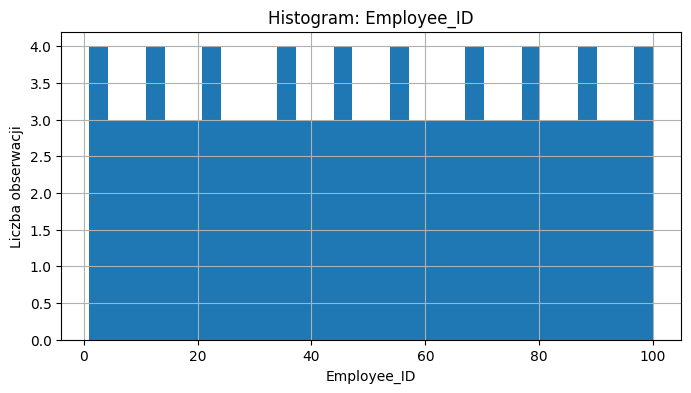

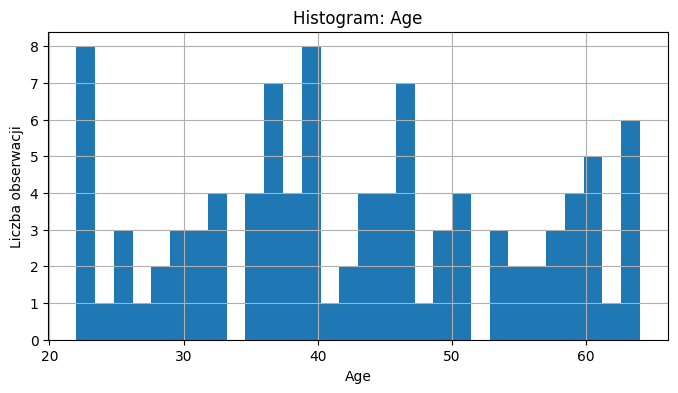

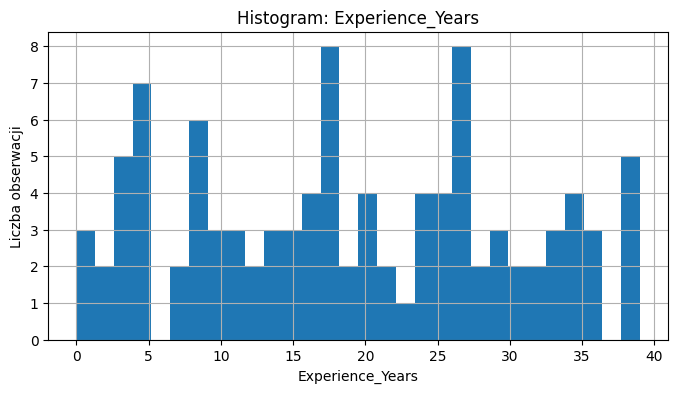

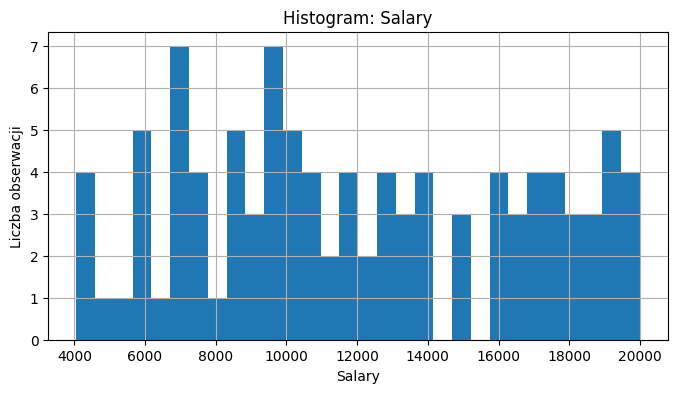

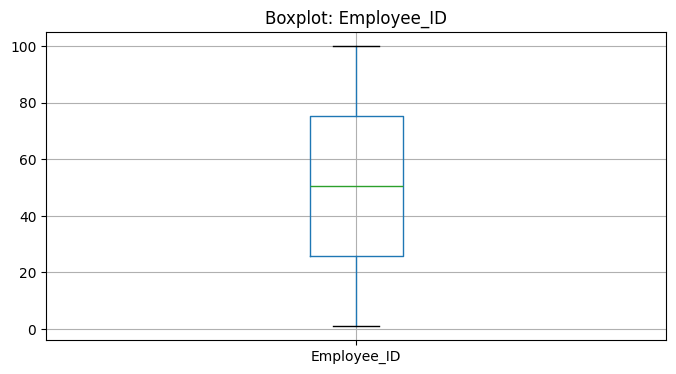

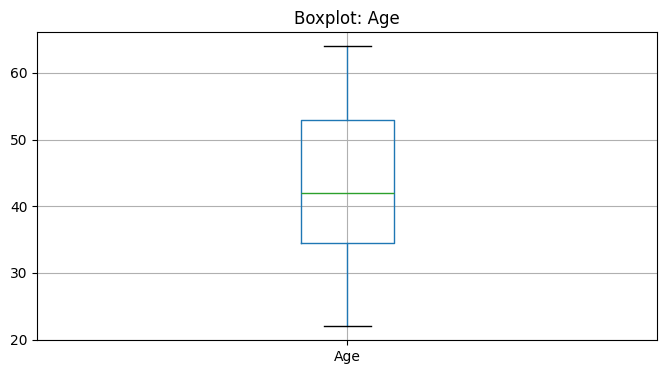

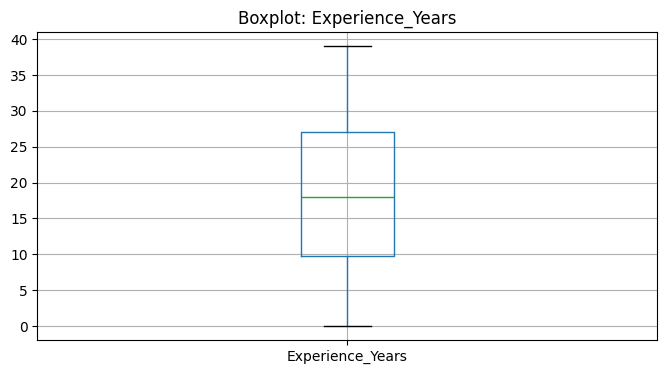

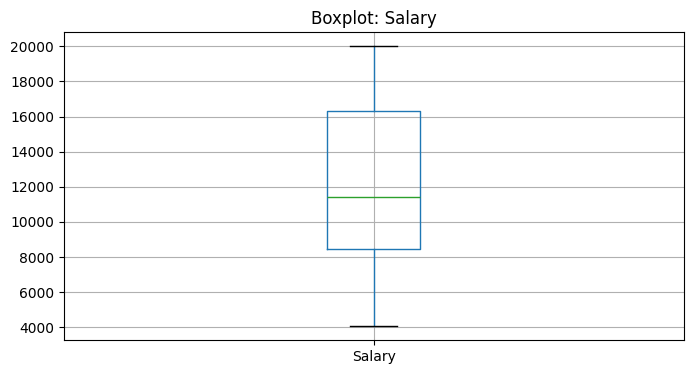

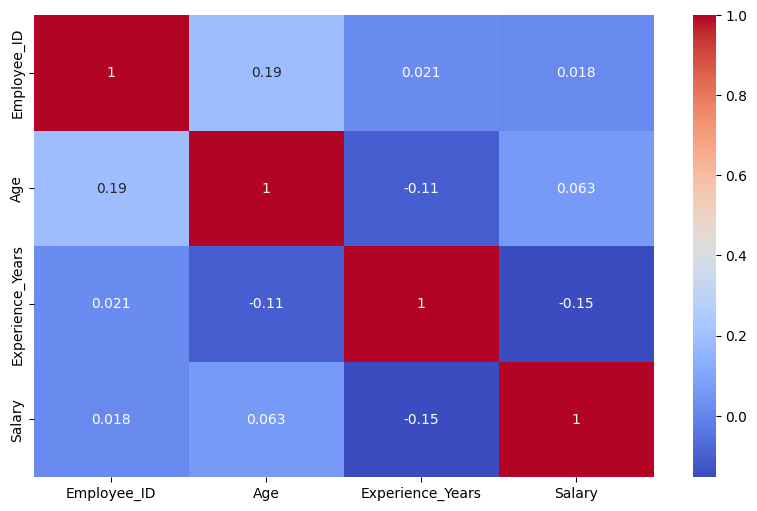

In [3]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczba obserwacji")
    plt.show()

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.show()

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Co wyszło: Wykresy potwierdziły, że staż pracy mocno łączy się z kasą. Rozkłady wyglądają normalnie, a na boxplotach widać parę osób z bardzo wysoką pensją.

In [4]:
data = df.copy()

for col in numeric_cols:
    if data[col].isna().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

cat_cols = data.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    if data[col].isna().sum() > 0:
        data[col] = data[col].fillna("brak_danych")

data_encoded = pd.get_dummies(data, drop_first=True)

target_col = "Salary"
X = data_encoded.drop([target_col, 'Employee_ID'], axis=1, errors='ignore')
y = data_encoded[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Co zrobiłem: Wyrzuciłem ID i imiona, bo tylko śmiecą. Działy zamieniłem na liczby (0/1), a wszystko inne przeskalowałem StandardScalerem, żeby model lepiej liczył.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred_reg = reg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_reg)
mae = mean_absolute_error(y_test, y_pred_reg)
print(f"MSE: {mse}, MAE: {mae}")

MSE: 19408282.17311523, MAE: 3792.616985621405


Podsumowanie: Hipoteza się sprawdziła – doświadczenie rządzi. Model regresji działa, błąd MAE pokazuje, o ile średnio się myli. Na przyszłość można sprawdzić trudniejsze modele, np. lasy losowe.